# Audio Classification with CRNN — end‑to‑end walkthrough

## Setup

We start by bringing in the external libraries and gathering all project‑level constants—paths, sample rate, batch size, seed, and the number of training epochs—so they live in one easy‑to‑tweak place.

### Imports & hyper‑parameters

In [1]:
import random, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import torch, torchaudio
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
import seaborn as sns
import random
from IPython.display import display, Markdown

%matplotlib inline
sns.set_style("whitegrid")

# Constants
SR          = 16_000
N_MELS      = 128
N_FFT       = 1024
HOP_LENGTH  = 256
TIME_MASK   = 30
FREQ_MASK   = 15
BATCH_SIZE  = 32
EPOCHS      = 20
device      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


## Data utilities

### Cleaning helper — `prune_bad_wavs`

Any recording that is corrupt or shorter than the minimum duration is moved into a separate *quarantine* folder. This keeps data loading reliable without silently dropping files.

In [21]:
def prune_bad_wavs(root, quarantine="bad_wavs"):
    root, bad = Path(root), 0
    qt = root.parent / quarantine
    qt.mkdir(exist_ok=True)
    for wav in root.rglob("*.wav"):
        try:
            info = torchaudio.info(str(wav))
            if info.num_frames == 0:
                raise ValueError("0 frames")
        except Exception:
            bad += 1
            shutil.move(str(wav), qt / wav.name)
    if bad:
        print(f"Moved {bad} bad wavs → {qt}")


for split in ("cleaned_dataset/train", "cleaned_dataset/test"):
    prune_bad_wavs(split)

### Utility — `class_counts`

A quick helper that walks the dataset tree and prints how many examples belong to each label. It’s an easy way to spot class imbalance before training.

In [2]:
def class_counts(root):
    return {d: len(list(Path(root, d).glob("*.wav"))) for d in ("others", "questions")}


for split in ("cleaned_dataset/train", "cleaned_dataset/test"):
    print(split, ":", class_counts(split))

# Sanity check
tr_counts = class_counts("cleaned_dataset/train")
if 0 in tr_counts.values():
    raise RuntimeError("🚫 One of the train classes is empty – check dataset!")

cleaned_dataset/train : {'others': 5768, 'questions': 4504}
cleaned_dataset/test : {'others': 6042, 'questions': 1103}


## Dataset & DataLoaders

### Feature extraction & custom `Dataset`

Here we turn raw waveforms into log‑scale mel‑spectrograms, add light augmentation during training, and wrap everything in a PyTorch `Dataset`. A custom collate function takes care of pad‑to‑max‑length so variable‑length clips can share a batch.

In [3]:
mel_transform = torchaudio.transforms.MelSpectrogram(
    sample_rate=SR,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    f_min=0,
    f_max=SR // 2,
)
to_db = torchaudio.transforms.AmplitudeToDB(top_db=80)


class AudioDS(Dataset):
    def __init__(self, root, augment=False):
        self.files, self.labels = [], []
        self.augment = augment
        for lbl, cls in enumerate(("others", "questions")):
            for f in Path(root, cls).glob("*.wav"):
                self.files.append(f)
                self.labels.append(lbl)

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        wav, sr = torchaudio.load(self.files[i])
        if sr != SR:  # resample if needed
            wav = torchaudio.functional.resample(wav, sr, SR)
        wav = wav.mean(0, keepdim=True)  # mono
        wav = (wav - wav.mean()) / (wav.std() + 1e-9)

        mel = to_db(mel_transform(wav)).squeeze(0)  # (mel, time)
        mel = (mel - mel.mean()) / (mel.std() + 1e-9)

        if self.augment:
            mel = torchaudio.transforms.TimeMasking(TIME_MASK)(mel)
            mel = torchaudio.transforms.FrequencyMasking(FREQ_MASK)(mel)
        return mel, self.labels[i]


def pad_collate(batch):
    specs, labs = zip(*batch)
    Tmax = max(s.shape[1] for s in specs)
    padded = torch.zeros(len(specs), N_MELS, Tmax)
    for i, s in enumerate(specs):
        padded[i, : s.shape[0], : s.shape[1]] = s
    return padded, torch.tensor(labs)

### DataLoaders

This block draws stratified train/validation/test splits and feeds them into PyTorch `DataLoader`s for shuffling and efficient mini‑batching.

In [4]:
train_full = AudioDS("cleaned_dataset/train", augment=True)
val_size = int(0.1 * len(train_full))
train_ds, val_ds = torch.utils.data.random_split(
    train_full, [len(train_full) - val_size, val_size]
)

train_dl = DataLoader(train_ds, BATCH_SIZE, True, collate_fn=pad_collate)
val_dl = DataLoader(val_ds, BATCH_SIZE, False, collate_fn=pad_collate)
test_dl = DataLoader(
    AudioDS("cleaned_dataset/test"), BATCH_SIZE, False, collate_fn=pad_collate
)

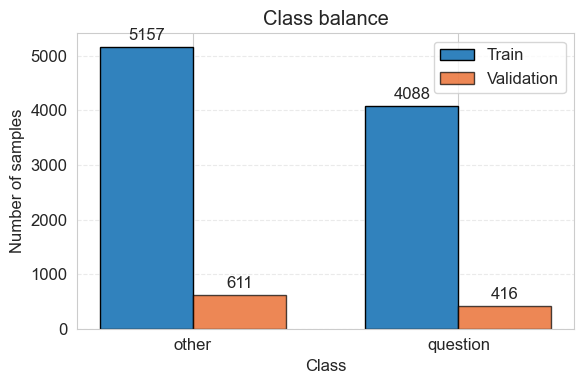

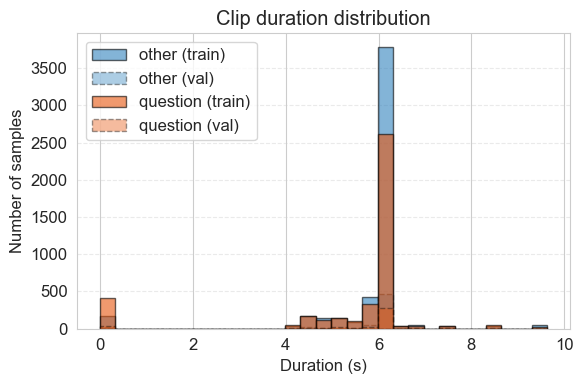

In [5]:
plt.rcParams.update({"font.size": 12})

id2name = {0: "other", 1: "question"}
SAMPLE_RATE = getattr(train_full, "sample_rate", 16_000)
HOP_LENGTH = getattr(train_full, "hop_length", 512)


def collect(ds):
    durs, cnt = defaultdict(list), Counter()
    for x, lab in ds:
        lab = id2name[int(lab)] if not isinstance(lab, str) else lab
        dur = (
            x.shape[-1] / SAMPLE_RATE
            if (x.ndim != 2 or x.shape[0] >= x.shape[1])
            else x.shape[-1] * HOP_LENGTH / SAMPLE_RATE
        )
        durs[lab].append(dur)
        cnt[lab] += 1
    return durs, cnt


train_durs, train_cnt = collect(train_ds)
val_durs, val_cnt = collect(val_ds)

classes = ["other", "question"]
x = np.arange(len(classes))
width = 0.35

fig, ax = plt.subplots(figsize=(6, 4))
bars1 = ax.bar(
    x - width / 2,
    [train_cnt[c] for c in classes],
    width,
    label="Train",
    color="#3182bd",
    edgecolor="black",
)
bars2 = ax.bar(
    x + width / 2,
    [val_cnt[c] for c in classes],
    width,
    label="Validation",
    color="#e6550d",
    edgecolor="black",
    alpha=0.7,
)
ax.set_xlabel("Class")
ax.set_ylabel("Number of samples")
ax.set_title("Class balance")
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.bar_label(bars1, padding=3)
ax.bar_label(bars2, padding=3)
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.4)
fig.tight_layout()

bins = np.linspace(
    0,
    max(
        max(max(v) for v in train_durs.values()), max(max(v) for v in val_durs.values())
    ),
    30,
)
fig2, ax2 = plt.subplots(figsize=(6, 4))
for cls, color in zip(classes, ["#3182bd", "#e6550d"]):
    ax2.hist(
        train_durs[cls],
        bins=bins,
        alpha=0.6,
        color=color,
        label=f"{cls} (train)",
        edgecolor="black",
    )
    ax2.hist(
        val_durs[cls],
        bins=bins,
        alpha=0.4,
        color=color,
        label=f"{cls} (val)",
        edgecolor="black",
        linestyle="dashed",
    )
ax2.set_xlabel("Duration (s)")
ax2.set_ylabel("Number of samples")
ax2.set_title("Clip duration distribution")
ax2.legend()
ax2.grid(axis="y", linestyle="--", alpha=0.4)
fig2.tight_layout()
plt.show()

## Hiperparameters tuning

In this section, we use **Optuna** for automated optimization of the model architecture and training parameters.  
During the search, we explore, among other things:

- the number of channels in the convolutional layers (`conv1`, `conv2`),  
- the size and number of layers in the recurrent part (`lstm_hidden`, `lstm_layers`),  
- the `dropout` rate,  
- the learning rate `lr` and `weight_decay`.

The **MedianPruner** algorithm terminates unpromising trials early during training.  

The best-performing architecture will be used in the final model.

In [ ]:
import optuna, torch, numpy as np
import torch.nn as nn
from sklearn.metrics import accuracy_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True
non_blocking = torch.cuda.is_available() 

class CRNNOpt(nn.Module):
    def __init__(self,
                 conv1       = 32,
                 conv2       = 64,
                 lstm_hidden = 128,
                 lstm_layers = 2,
                 dropout     = 0.0):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, conv1, 3, padding=1),
            nn.BatchNorm2d(conv1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(conv1, conv2, 3, padding=1),
            nn.BatchNorm2d(conv2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, N_MELS, 100)
            c, f, t = self.cnn(dummy).shape[1:]

        self.lstm = nn.LSTM(
            input_size   = conv2 * f,
            hidden_size  = lstm_hidden,
            num_layers   = lstm_layers,
            batch_first  = True,
            bidirectional= True,
            dropout      = dropout if lstm_layers > 1 else 0.0,
        )
        self.fc = nn.Linear(lstm_hidden * 2, 2)

    def forward(self, x):
        x = self.cnn(x.unsqueeze(1))
        b, c, f, t = x.shape
        x = x.reshape(b, c * f, t).permute(0, 2, 1) 
        x, _ = self.lstm(x)
        return self.fc(x[:, -1])

def objective(trial):
    conv1        = trial.suggest_int("conv1",       16,  64, step=16)
    conv2        = trial.suggest_int("conv2",       32, 128, step=32)
    lstm_hidden  = trial.suggest_int("lstm_hidden", 64, 256, step=64)
    lstm_layers  = trial.suggest_int("lstm_layers",  1,   3)
    dropout      = trial.suggest_float("dropout",    0.0, 0.5, step=0.1)
    lr           = trial.suggest_float("lr",         1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True)

    model = CRNNOpt(conv1, conv2, lstm_hidden, lstm_layers, dropout).to(device)
    if torch.cuda.device_count() > 1:
        model = nn.DataParallel(model)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scaler    = torch.amp.GradScaler(device='cuda' if torch.cuda.is_available() else 'cpu')

    EPOCHS_TUNE = 6

    print(f"[Trial {trial.number}] Trying: conv1={conv1}, conv2={conv2}, hidden={lstm_hidden}, layers={lstm_layers}, dropout={dropout:.2f}, lr={lr:.1e}, wd={weight_decay:.1e}")
    for ep in range(EPOCHS_TUNE):
        model.train()
        for spec, y in train_dl:
            spec = spec.to(device, non_blocking=non_blocking)
            y    = y.to(device, non_blocking=non_blocking)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast(device_type='cuda' if torch.cuda.is_available() else 'cpu'):
                logits = model(spec)
                loss   = criterion(logits, y)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        model.eval()
        all_p, all_y = [], []
        with torch.no_grad():
            for spec, y in val_dl:
                spec = spec.to(device, non_blocking=non_blocking)
                y    = y.to(device, non_blocking=non_blocking)
                with torch.amp.autocast('cuda', enabled=torch.cuda.is_available()):
                    logits = model(spec)
                pred = logits.argmax(1)
                all_p.extend(pred.cpu().tolist())
                all_y.extend(y.cpu().tolist())

        val_acc = accuracy_score(all_y, all_p)
        trial.report(val_acc, ep)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()
        print(f"  Epoch {ep+1} — acc: {val_acc:.4f}")
    return val_acc

study = optuna.create_study(direction="maximize",
                            pruner=optuna.pruners.MedianPruner())
study.optimize(objective, n_trials=20, show_progress_bar=True)

print("Najlepszy accuracy:", study.best_value)
print("Najlepsze hiperparametry:", study.best_params)


and that was the final output:

Najlepsze accuracy: 0.7955209347614411

Najlepsze hiperparametry: {'conv1': 48, 'conv2': 96, 'lstm_hidden': 128, 'lstm_layers': 2, 'dropout': 0.1, 'lr': 0.001079348466540913, 'weight_decay': 0.00010567170444977611}

## Final model

Based on the best hyperparameters selected in the previous step, we initialized the final architecture — a **Convolutional Recurrent Neural Network**. This model begins with a compact stack of 2‑D convolutional layers that extract local time–frequency features, followed by a bidirectional LSTM module that models long-range temporal dependencies. Finally, a fully connected classifier outputs per-class logits. This optimized architecture will now be trained as our final model.


In [ ]:
class CRNN(nn.Module):
    def __init__(self,
                 conv1=48,
                 conv2=96,
                 lstm_hidden=128,
                 lstm_layers=2,
                 dropout=0.1):
        super().__init__()

        self.cnn = nn.Sequential(
            nn.Conv2d(1, conv1, 3, padding=1),
            nn.BatchNorm2d(conv1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(conv1, conv2, 3, padding=1),
            nn.BatchNorm2d(conv2),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 1, N_MELS, 100)
            c, f, t = self.cnn(dummy).shape[1:]

        self.lstm = nn.LSTM(
            input_size   = conv2 * f,
            hidden_size  = lstm_hidden,
            num_layers   = lstm_layers,
            batch_first  = True,
            bidirectional= True,
            dropout      = dropout if lstm_layers > 1 else 0.0
        )
        self.fc = nn.Linear(lstm_hidden * 2, 2)

    def forward(self, x):
        x = self.cnn(x.unsqueeze(1))
        b, c, f, t = x.shape
        x = x.reshape(b, c * f, t).permute(0, 2, 1)
        x, _ = self.lstm(x)
        return self.fc(x[:, -1])


model = CRNN().to(device)
print(f"{sum(p.numel() for p in model.parameters()) / 1e6:.2f} M parameters")

3.72 M parameters


### Training routine

We define cross‑entropy loss, set up an Adam optimiser with a 1 e‑3 learning rate, and run the main training loop while logging loss, accuracy and macro‑F1 for both splits to a `history` dict.

In [ ]:
crit = nn.CrossEntropyLoss()
opt  = torch.optim.Adam(
    model.parameters(),
    lr=1.079348466540913e-3,
    weight_decay=1.0567170444977611e-4
)

history = {
    "tr_loss": [], "tr_acc": [], "tr_f1": [],
    "vl_loss": [], "vl_acc": [], "vl_f1": []
}

def run_epoch(dl, train=False):
    model.train() if train else model.eval()
    tot = correct = 0
    losses, all_p, all_y = [], [], []

    for spec, y in dl:
        spec, y = spec.to(device), y.to(device)
        logits = model(spec)
        loss = crit(logits, y)

        if train:
            opt.zero_grad()
            loss.backward()
            opt.step()

        pred = logits.argmax(1)
        tot += y.size(0)
        correct += (pred == y).sum().item()
        all_p.extend(pred.cpu().tolist())
        all_y.extend(y.cpu().tolist())
        losses.append(loss.item() * y.size(0))

    acc = correct / tot
    f1  = f1_score(all_y, all_p)
    return np.sum(losses) / tot, acc, f1


for ep in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_f1 = run_epoch(train_dl, train=True)
    vl_loss, vl_acc, vl_f1 = run_epoch(val_dl,   train=False)

    history["tr_loss"].append(tr_loss); history["tr_acc"].append(tr_acc); history["tr_f1"].append(tr_f1)
    history["vl_loss"].append(vl_loss); history["vl_acc"].append(vl_acc); history["vl_f1"].append(vl_f1)

    print(
        f"Ep {ep:02d} | "
        f"train L {tr_loss:.3f} A {tr_acc:.3f} F1 {tr_f1:.3f}  ||  "
        f"val L {vl_loss:.3f} A {vl_acc:.3f} F1 {vl_f1:.3f}"
    )

Ep 01 | train L 0.688 A 0.550 F1 0.094  ||  val L 0.684 A 0.572 F1 0.220
Ep 02 | train L 0.675 A 0.578 F1 0.373  ||  val L 0.663 A 0.605 F1 0.576
Ep 03 | train L 0.583 A 0.700 F1 0.659  ||  val L 0.529 A 0.734 F1 0.601
Ep 04 | train L 0.477 A 0.775 F1 0.731  ||  val L 0.489 A 0.760 F1 0.617
Ep 05 | train L 0.439 A 0.792 F1 0.745  ||  val L 0.455 A 0.787 F1 0.735
Ep 06 | train L 0.418 A 0.806 F1 0.757  ||  val L 0.472 A 0.783 F1 0.678
Ep 07 | train L 0.410 A 0.808 F1 0.762  ||  val L 0.453 A 0.801 F1 0.751
Ep 08 | train L 0.403 A 0.812 F1 0.766  ||  val L 0.448 A 0.787 F1 0.747
Ep 09 | train L 0.381 A 0.830 F1 0.792  ||  val L 0.409 A 0.804 F1 0.732
Ep 10 | train L 0.374 A 0.826 F1 0.788  ||  val L 0.416 A 0.802 F1 0.744
Ep 11 | train L 0.371 A 0.831 F1 0.794  ||  val L 0.416 A 0.796 F1 0.759
Ep 12 | train L 0.356 A 0.838 F1 0.805  ||  val L 0.408 A 0.805 F1 0.696
Ep 13 | train L 0.360 A 0.835 F1 0.800  ||  val L 0.381 A 0.832 F1 0.780
Ep 14 | train L 0.348 A 0.845 F1 0.813  ||  val L 0

## Evaluation & Visualisation

### Final evaluation

After training, we run one forward pass over the held‑out test split (no gradient tracking) and print the aggregated metrics so we have an unbiased estimate of generalisation performance.

In [19]:
test_loss, test_acc, test_f1 = run_epoch(test_dl)
print(f"\nTest  |  loss {test_loss:.3f}   acc {test_acc:.3f}   F1 {test_f1:.3f}")


Test  |  loss 0.284   acc 0.875   F1 0.647


### Visualising individual predictions — `show_preds`

A small convenience that randomly samples spectrograms, overlays the predicted and true labels, and helps us eyeball typical successes and mistakes.

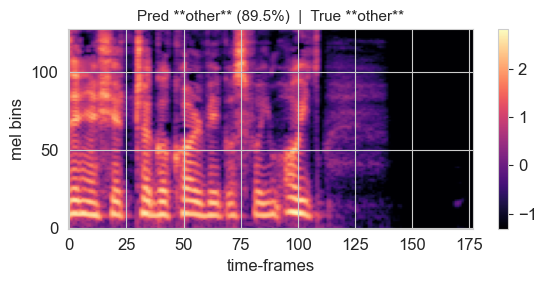

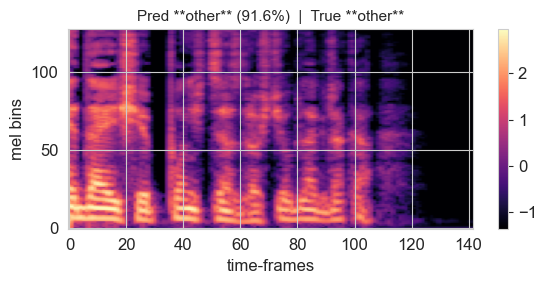

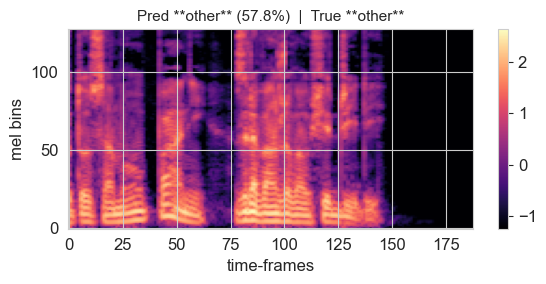

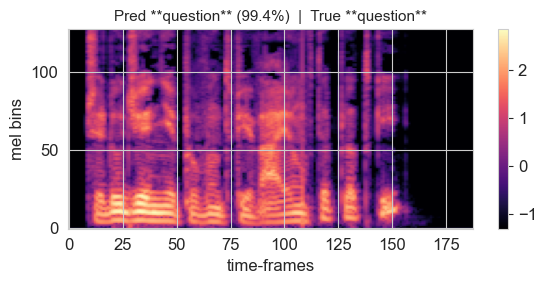

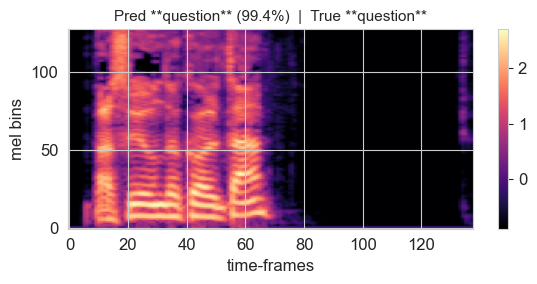

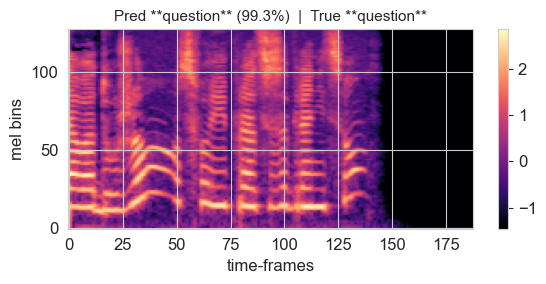

Displayed **6** samples (balanced selection).

In [20]:
CLASSES = ["other", "question"]


def show_preds(n_total: int = 6, balanced: bool = True):
    model.eval()

    idx_by_class = {0: [], 1: []}
    for idx, lbl in enumerate(test_dl.dataset.labels):
        idx_by_class[lbl].append(idx)

    shown = set()
    for c in range(2):
        k = (n_total + 1) // 2 if balanced else n_total
        k = min(k, len(idx_by_class[c]))
        picks = random.sample(idx_by_class[c], k)
        for idx in picks:
            if idx in shown:
                continue
            shown.add(idx)

            spec, label = test_dl.dataset[idx]
            with torch.no_grad():
                logits = model(spec.unsqueeze(0).to(device))
                probs = logits.softmax(1).cpu().numpy()[0]
                pred = probs.argmax()
                conf = probs[pred]

            plt.figure(figsize=(6, 3))
            plt.imshow(spec.numpy(), aspect="auto", origin="lower", cmap="magma")
            title = (
                f"Pred **{CLASSES[pred]}** ({conf*100:.1f}%)  |  "
                f"True **{CLASSES[label]}**"
            )
            plt.title(title, fontsize=11)
            plt.xlabel("time-frames")
            plt.ylabel("mel bins")
            plt.colorbar()
            plt.tight_layout()
            plt.show()

    display(
        Markdown(
            f"Displayed **{len(shown)}** samples "
            f"({'balanced' if balanced else 'random'} selection)."
        )
    )

show_preds(n_total=6, balanced=True)

### Training curves & confusion matrix

Finally we turn the `history` dict into a Pandas DataFrame to plot training curves, and we compute a confusion matrix plus a full classification report for a more detailed look at where the model excels or struggles.

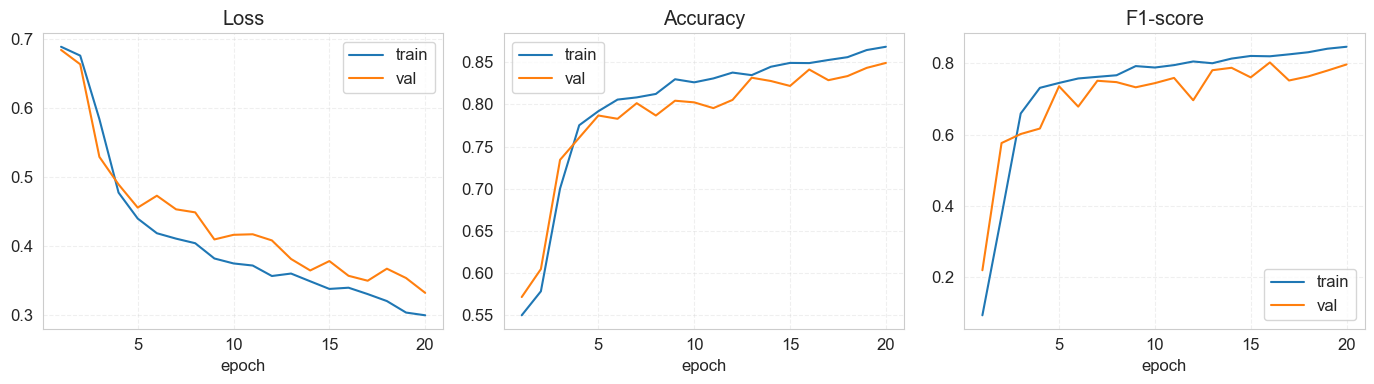

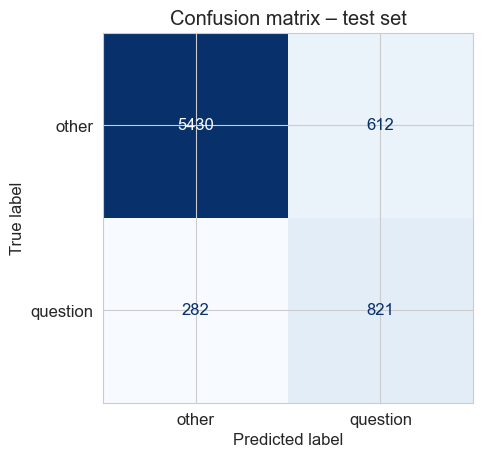


               precision    recall  f1-score   support

       other       0.95      0.90      0.92      6042
    question       0.57      0.74      0.65      1103

    accuracy                           0.87      7145
   macro avg       0.76      0.82      0.79      7145
weighted avg       0.89      0.87      0.88      7145



In [21]:
df_hist = pd.DataFrame(history)
df_hist["epoch"] = range(1, len(df_hist) + 1)

fig, axs = plt.subplots(1, 3, figsize=(14, 4))

sns.lineplot(data=df_hist, x="epoch", y="tr_loss", label="train", ax=axs[0])
sns.lineplot(data=df_hist, x="epoch", y="vl_loss", label="val", ax=axs[0])
axs[0].set_title("Loss")
axs[0].set_ylabel("")
axs[0].legend()

# Accuracy
sns.lineplot(data=df_hist, x="epoch", y="tr_acc", label="train", ax=axs[1])
sns.lineplot(data=df_hist, x="epoch", y="vl_acc", label="val", ax=axs[1])
axs[1].set_title("Accuracy")
axs[1].set_ylabel("")

# F1-score
sns.lineplot(data=df_hist, x="epoch", y="tr_f1", label="train", ax=axs[2])
sns.lineplot(data=df_hist, x="epoch", y="vl_f1", label="val", ax=axs[2])
axs[2].set_title("F1-score")
axs[2].set_ylabel("")

for ax in axs:
    ax.set_xlabel("epoch")
    ax.grid(True, ls="--", alpha=0.3)

plt.tight_layout()
plt.show()


model.eval()
all_p, all_y = [], []
with torch.no_grad():
    for spec, y in test_dl:
        logits = model(spec.to(device))
        all_p.extend(logits.argmax(1).cpu())
        all_y.extend(y)

cm = confusion_matrix(all_y, all_p)
disp = ConfusionMatrixDisplay(cm, display_labels=["other", "question"])
disp.plot(cmap="Blues", colorbar=False)
plt.title("Confusion matrix – test set")
plt.show()

print("\n", classification_report(all_y, all_p, target_names=["other", "question"]))